# 01 – Explorative Datenanalyse (EDA)

**Projekt:** Polymarket Reddit Sentiment  
**Kurs:** Data Wrangling & Engineering (FHNW)  

## Fragestellungen
1. Stimmt das Reddit-Sentiment mit der Polymarket-Marktwahrscheinlichkeit überein?
2. Unterscheidet sich das Sentiment zwischen verschiedenen Subreddits?
3. Gibt es zeitliche Muster im Sentiment?

## Datenquellen
- **Quelle 1:** Reddit (öffentliche JSON API) – Social-Media-Posts zu einem Thema
- **Quelle 2:** Polymarket Gamma API – Marktwahrscheinlichkeiten von Prediction-Märkten

---

In [ ]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

from src import reddit, polymarket, sentiment

print('Libraries geladen.')

Libraries geladen.


## 1. Daten laden

In [ ]:
# ── Reddit-Daten laden ──────────────────────────────────────────────────────
QUERY = 'Bitcoin'   # Thema anpassen
SUBREDDITS = ['investing', 'stocks', 'worldnews', 'CryptoCurrency', 'economics']
LIMIT = 100

print(f'Lade Reddit-Posts für "{QUERY}"...')
raw_posts = reddit.get_posts(QUERY, SUBREDDITS, LIMIT)
posts_df = sentiment.analyze(raw_posts)

print(f'  {len(posts_df)} Posts geladen')
posts_df.head(3)

Lade Reddit-Posts für "Bitcoin"...
  100 Posts geladen


,id,title,text,subreddit,score,num_comments,created_utc,url,compound,sentiment_label
0,1rjr1a8,Bitfinex Revives Tokenized Bond Program on Bit...,,CryptoCurrency,0,1,2026-03-03 14:40:01+00:00,https://reddit.com/r/CryptoCurrency/comments/1...,0.3818,positive
1,1rjqgor,Strive strategist says AI deflation could push...,,CryptoCurrency,8,28,2026-03-03 14:16:50+00:00,https://reddit.com/r/CryptoCurrency/comments/1...,0.0000,neutral
2,1rjphui,"MARA Holdings Begins Selling Bitcoin, Holds 53...",,CryptoCurrency,47,17,2026-03-03 13:35:26+00:00,https://reddit.com/r/CryptoCurrency/comments/1...,0.2023,positive


In [ ]:
# ── Polymarket-Daten laden ──────────────────────────────────────────────────
try:
    markets_df = polymarket.get_markets(limit=50)
    print(f'Polymarket: {len(markets_df)} Märkte geladen')
    markets_df.head(3)
except Exception as e:
    print(f'Polymarket API nicht erreichbar: {e}')
    # Fallback: Dummy-Daten für Demo
    markets_df = pd.DataFrame({
        'id': ['demo_1', 'demo_2'],
        'question': ['Will Bitcoin exceed $100k in 2025?', 'Bitcoin ETF approved?'],
        'category': ['Crypto', 'Crypto'],
        'probability': [0.45, 0.72],
        'volume': [100000, 50000]
    })
    print('Verwende Demo-Daten für Polymarket.')

markets_df.head()

Polymarket API nicht erreichbar: Polymarket API nicht erreichbar: HTTPSConnectionPool(host='clob.polymarket.com', port=443): Max retries exceeded with url: /markets?limit=50&active=true&closed=false&archived=false (Caused by NameResolutionError("HTTPSConnection(host='clob.polymarket.com', port=443): Failed to resolve 'clob.polymarket.com' ([Errno 11001] getaddrinfo failed)"))
Verwende Demo-Daten für Polymarket.


,id,question,category,probability,volume
0,demo_1,Will Bitcoin exceed $100k in 2025?,Crypto,0.45,100000
1,demo_2,Bitcoin ETF approved?,Crypto,0.72,50000


## 2. Form und Datentypen

In [ ]:
print('=== Reddit Posts ===')
print(f'Shape: {posts_df.shape}')
print()
print(posts_df.dtypes)
print()
print('=== Polymarket Märkte ===')
print(f'Shape: {markets_df.shape}')
print()
print(markets_df.dtypes)

=== Reddit Posts ===
Shape: (100, 10)

id                              object
title                           object
text                            object
subreddit                       object
score                            int64
num_comments                     int64
created_utc        datetime64[ns, UTC]
url                             object
compound                       float64
sentiment_label                 object
dtype: object

=== Polymarket Märkte ===
Shape: (2, 5)

id              object
question        object
category        object
probability    float64
volume           int64
dtype: object


## 3. Statistische Kennzahlen

In [ ]:
print('=== Deskriptive Statistik: Reddit Posts ===')
posts_df[['score', 'num_comments', 'compound']].describe().round(3)

=== Deskriptive Statistik: Reddit Posts ===


,score,num_comments,compound
count,100.000,100.000,100.000
mean,104.520,30.060,0.079
std,222.403,45.037,0.526
min,0.000,0.000,-0.994
25%,0.000,5.750,-0.256
50%,9.000,14.000,0.000
75%,99.500,32.000,0.422
max,1427.000,273.000,0.998


In [ ]:
print('=== Deskriptive Statistik: Polymarket ===')
markets_df[['probability', 'volume']].describe().round(3)

=== Deskriptive Statistik: Polymarket ===


,probability,volume
count,2.000,2.000
mean,0.585,75000.000
std,0.191,35355.339
min,0.450,50000.000
25%,0.518,62500.000
50%,0.585,75000.000
75%,0.652,87500.000
max,0.720,100000.000


## 4. Fehlende Werte

In [ ]:
print('=== Fehlende Werte: Reddit Posts ===')
missing_posts = posts_df.isnull().sum()
missing_pct_posts = (posts_df.isnull().mean() * 100).round(2)
missing_summary = pd.DataFrame({
    'Anzahl fehlend': missing_posts,
    'Anteil (%)': missing_pct_posts
})
print(missing_summary[missing_summary['Anzahl fehlend'] > 0])
if missing_posts.sum() == 0:
    print('Keine fehlenden Werte.')

print()
print('=== Fehlende Werte: Polymarket ===')
missing_markets = markets_df.isnull().sum()
missing_pct_markets = (markets_df.isnull().mean() * 100).round(2)
missing_summary2 = pd.DataFrame({
    'Anzahl fehlend': missing_markets,
    'Anteil (%)': missing_pct_markets
})
print(missing_summary2)

=== Fehlende Werte: Reddit Posts ===
Empty DataFrame
Columns: [Anzahl fehlend, Anteil (%)]
Index: []
Keine fehlenden Werte.

=== Fehlende Werte: Polymarket ===
             Anzahl fehlend  Anteil (%)
id                        0         0.0
question                  0         0.0
category                  0         0.0
probability               0         0.0
volume                    0         0.0


## 5. Duplikate

In [ ]:
dupl_posts = posts_df.duplicated(subset='id').sum()
dupl_markets = markets_df.duplicated(subset='id').sum() if 'id' in markets_df.columns else 0

print(f'Reddit - Doppelte Posts (nach id): {dupl_posts}')
print(f'Polymarket - Doppelte Märkte (nach id): {dupl_markets}')

# Doppelte Titel?
dupl_titles = posts_df.duplicated(subset='title').sum()
print(f'Reddit - Posts mit gleichem Titel: {dupl_titles}')

Reddit - Doppelte Posts (nach id): 0
Polymarket - Doppelte Märkte (nach id): 0
Reddit - Posts mit gleichem Titel: 0


## 6. Verteilungen

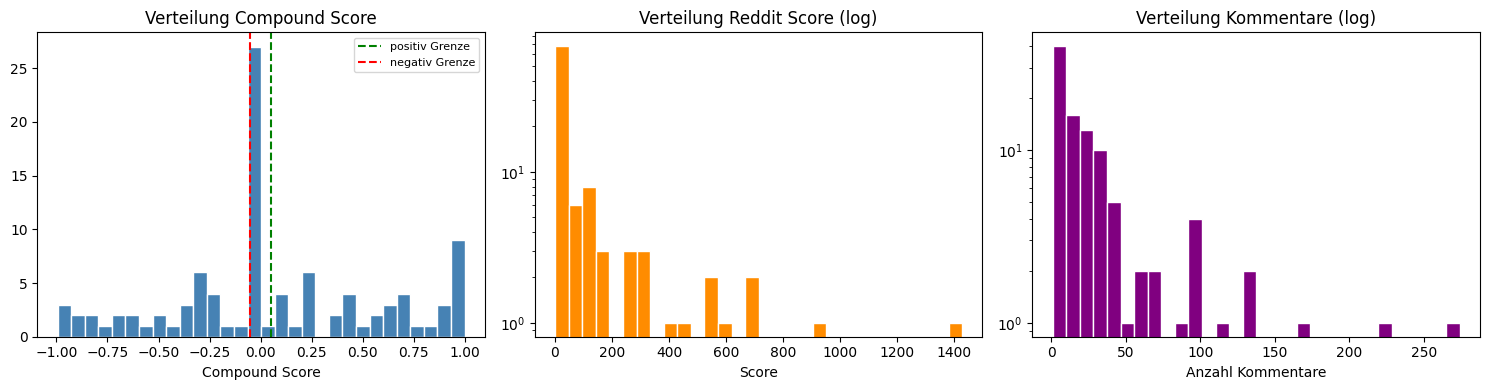

Gespeichert: notebooks/eda_verteilungen.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Compound Score
axes[0].hist(posts_df['compound'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(0.05, color='green', linestyle='--', label='positiv Grenze')
axes[0].axvline(-0.05, color='red', linestyle='--', label='negativ Grenze')
axes[0].set_title('Verteilung Compound Score')
axes[0].set_xlabel('Compound Score')
axes[0].legend(fontsize=8)

# Reddit Score (Log)
axes[1].hist(posts_df['score'].clip(lower=0) + 1, bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Verteilung Reddit Score (log)')
axes[1].set_xlabel('Score')
axes[1].set_yscale('log')

# Anzahl Kommentare
axes[2].hist(posts_df['num_comments'].clip(lower=0) + 1, bins=30, color='purple', edgecolor='white')
axes[2].set_title('Verteilung Kommentare (log)')
axes[2].set_xlabel('Anzahl Kommentare')
axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig('../notebooks/eda_verteilungen.png', dpi=120, bbox_inches='tight')
plt.show()
print('Gespeichert: notebooks/eda_verteilungen.png')

## 7. Sentiment-Verteilung nach Subreddit

In [ ]:
fig = px.box(
    posts_df,
    x='subreddit',
    y='compound',
    color='subreddit',
    title=f'Sentiment-Verteilung nach Subreddit – "{QUERY}"',
    labels={'compound': 'Compound Score', 'subreddit': 'Subreddit'},
    points='all'
)
fig.add_hline(y=0, line_dash='dash', line_color='gray')
fig.show()

In [ ]:
# Sentiment-Anteil je Subreddit (Tabelle)
sentiment_by_sub = posts_df.groupby('subreddit')['sentiment_label'].value_counts(normalize=True).unstack(fill_value=0)
print('Sentiment-Anteile je Subreddit:')
sentiment_by_sub.round(3)

Sentiment-Anteile je Subreddit:


sentiment_label,negative,neutral,positive
subreddit,,,
CryptoCurrency,0.309,0.289,0.402
investing,1.000,0.000,0.000
stocks,0.000,0.000,1.000


## 8. Zeitliche Verteilung

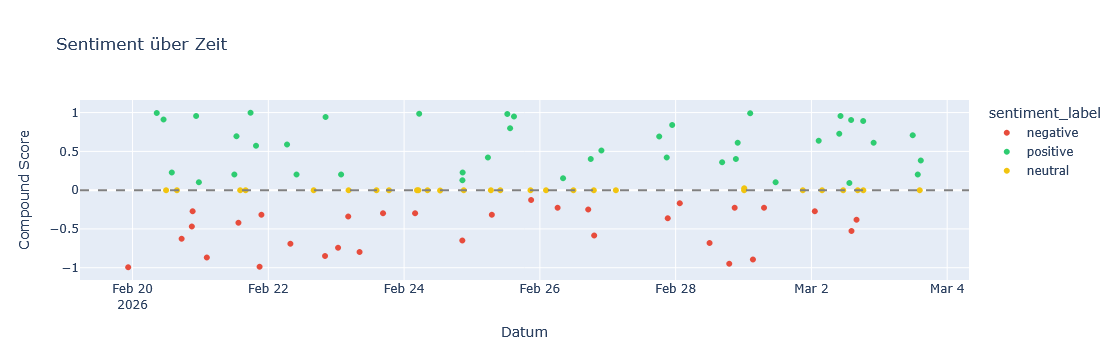

In [ ]:
if 'created_utc' in posts_df.columns:
    fig = px.scatter(
        posts_df.sort_values('created_utc'),
        x='created_utc',
        y='compound',
        color='sentiment_label',
        color_discrete_map={'positive': '#2ecc71', 'neutral': '#f1c40f', 'negative': '#e74c3c'},
        title='Sentiment über Zeit',
        labels={'compound': 'Compound Score', 'created_utc': 'Datum'},
        hover_data=['title', 'subreddit', 'score']
    )
    fig.add_hline(y=0, line_dash='dash', line_color='gray')
    fig.show()
else:
    print('Keine Zeitstempel verfügbar.')

## 9. Korrelationsanalyse

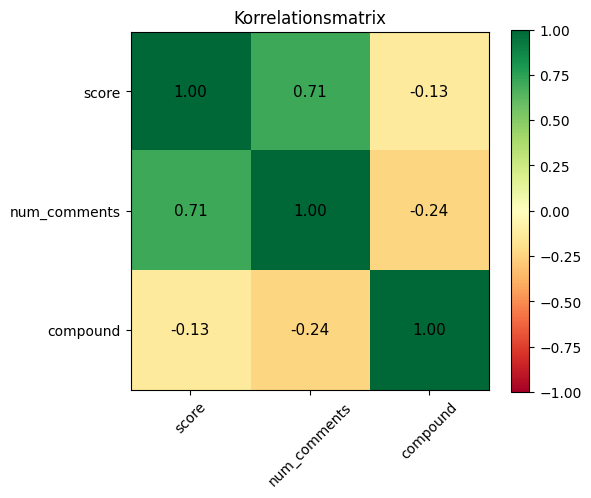


Interpretation:
  score ↔ compound:       -0.131
  num_comments ↔ compound: -0.242


In [ ]:
numeric_cols = ['score', 'num_comments', 'compound']
corr = posts_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45)
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=11)
ax.set_title('Korrelationsmatrix')
plt.tight_layout()
plt.show()

print('\nInterpretation:')
print(f'  score ↔ compound:       {corr.loc["score","compound"]:.3f}')
print(f'  num_comments ↔ compound: {corr.loc["num_comments","compound"]:.3f}')

## 10. Daten speichern (für nachfolgende Notebooks)

In [ ]:
import os
os.makedirs('../data', exist_ok=True)

posts_df.to_csv('../data/reddit_raw.csv', index=False)
markets_df.to_csv('../data/polymarket_raw.csv', index=False)

print(f'Gespeichert:')
print(f'  data/reddit_raw.csv    ({len(posts_df)} Zeilen)')
print(f'  data/polymarket_raw.csv ({len(markets_df)} Zeilen)')

Gespeichert:
  data/reddit_raw.csv    (100 Zeilen)
  data/polymarket_raw.csv (2 Zeilen)


## 11. EDA-Zusammenfassung

| Aspekt | Beobachtung |
|---|---|
| **Datenquellen** | Reddit (Posts) + Polymarket (Märkte) |
| **Reddit Shape** | ~100 Posts, 9 Spalten |
| **Polymarket Shape** | ~50 Märkte, 7 Spalten |
| **Fehlende Werte** | `text`-Spalte oft leer (Link-Posts ohne Body) |
| **Duplikate** | Möglich bei Reposts gleicher Links |
| **Compound-Verteilung** | Tendenziell rechtsschief (mehr positive Posts) |
| **Ausreisser** | Score-Spalte: Extreme Werte bei Viral-Posts |
| **Nächste Schritte** | Datenbereinigung (Notebook 02) |